In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys
import torch

PROJECT_ROOT = "/content/drive/MyDrive/Explainable Detection of Online Sexism"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
os.environ["EDOS_CONFIG"] = "/content/drive/MyDrive/Explainable Detection of Online Sexism/config/config_v2.yaml"

from src.pipeline import setup, run_rnn_binary, run_rnn_category, run_transformer_binary, run_transformer_category
from config.config import (
    DATA_PATH, GLOVE_PATH, EMBED_DIM, MAX_VOCAB, MAX_LEN, HIDDEN_DIM, BATCH_SIZE, BATCH_SIZE_TRANSFORMER,
    MODEL_NAME, TRANSFORMER_MAX_LEN, EPOCHS, PATIENCE, USE_FOCAL, FOCAL_GAMMA, BINARY_LABELS, CATEGORY_LABELS,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
state = setup(device)

print(f"Data        : {DATA_PATH}")
print(f"GloVe       : {GLOVE_PATH}")
print(f"Embed dim   : {EMBED_DIM}")
print(f"Transformer : {MODEL_NAME}")
print(f"Epochs      : {EPOCHS}  |  Patience: {PATIENCE}")
print(f"Use Focal   : {USE_FOCAL}  |  gamma: {FOCAL_GAMMA}")

Mounted at /content/drive
Device: cuda
Loading data ...
Binary   — train: 16000  test: 4000
Category — train: 3884  test: 970

Building vocab + loading GloVe ...
Vocabulary size: 20000
GloVe coverage: 17294 / 20000 ( 86.5%)

Building RNN loaders ...
Building Transformer loaders ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Binary weights  : tensor([0.6603, 2.0597], device='cuda:0')
Category weights: tensor([2.7429, 0.5344, 0.7290, 2.5486], device='cuda:0')
Data        : /content/drive/MyDrive/Explainable Detection of Online Sexism/Dataset/edos_clean.csv
GloVe       : /content/drive/MyDrive/Explainable Detection of Online Sexism/GloVe/glove.twitter.27B.200d.txt
Embed dim   : 200
Transformer : roberta-base
Epochs      : 25  |  Patience: 6
Use Focal   : False  |  gamma: 2.0



BiLSTM — Task A (Binary)
Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      0.5645     0.7299    0.6728    0.8255    0.7563    LR: 1.00e-03


2      0.4158     0.8253    0.7814    0.8275    0.7667    LR: 1.00e-03


3      0.3029     0.8823    0.8504    0.7850    0.7318    LR: 1.00e-03


4      0.1896     0.9306    0.9098    0.8307    0.7561    LR: 1.00e-03


5      0.1117     0.9646    0.9530    0.8167    0.7519    LR: 5.00e-04


6      0.0511     0.9850    0.9798    0.8153    0.7481    LR: 5.00e-04


7      0.0287     0.9912    0.9882    0.8167    0.7462    LR: 5.00e-04


8      0.0187     0.9948    0.9929    0.8035    0.7378    LR: 2.50e-04

Early stopping triggered

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not sexist       0.88      0.86      0.87      3030
      Sexist       0.59      0.62      0.61       970

    accuracy                           0.80      4000
   macro avg       0.73      0.74      0.74      4000
weighted avg       0.81      0.80      0.81      4000

Accuracy : 0.8035
Macro F1 : 0.7378
Weighted F1 : 0.8054

Confusion Matrix (raw):
[[2608  422]
 [ 364  606]]


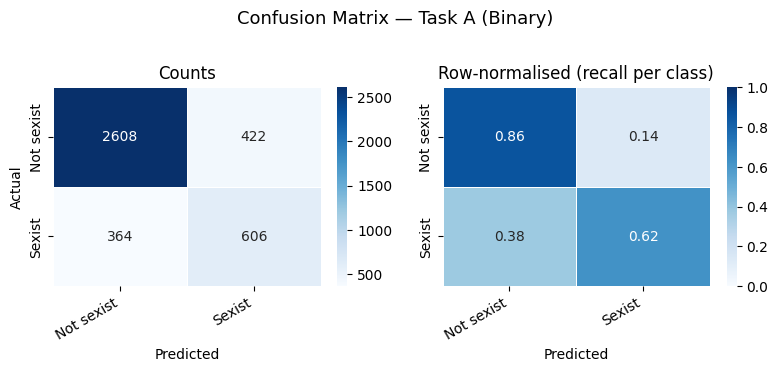

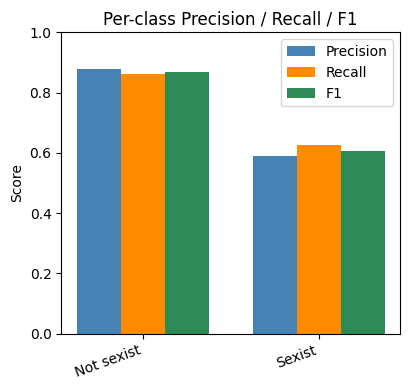


ERROR ANALYSIS

Total errors: 786 / 4000 (19.6%)

Error rate per true class:


,class,errors,total,error_rate (%)
1,Sexist,364,970,37.5
0,Not sexist,422,3030,13.9



Top confusion pairs (actual → predicted):


,actual,predicted,count
0,Not sexist,Sexist,422
1,Sexist,Not sexist,364


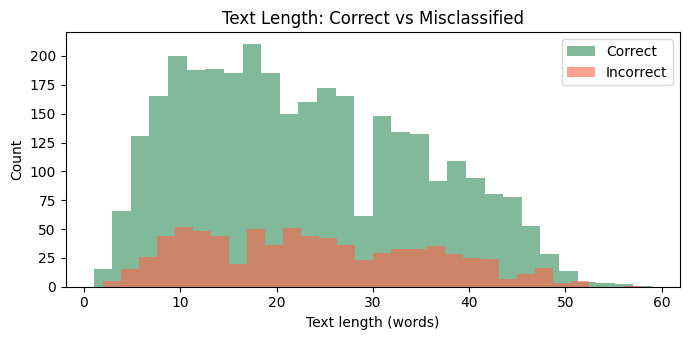


Sample misclassified examples:

  ✗ Actual: [Not sexist]  →  Predicted: [Sexist]  (n = 422)
    • (1.00) if your daughter is socializing with blacks, and visiting black areas, and partying around blacks - then the fact she ha
    • (0.96) you mean those videos where a woman slaps a guy when she's fucked up? we see those everyday already.
    • (0.98) true, most do lol i get hit on by more fat girls than anything else. but they usually settle for an out of shape guy. fi

  ✗ Actual: [Sexist]  →  Predicted: [Not sexist]  (n = 364)
    • (1.00) well then good because someone has to knock her ass back in line when she acts like a woman and posts bullshit about her
    • (0.80) yes, normal women want to be dominated. social scientists call it female hypergamy. and it is why women make bad bosses 
    • (1.00) i would pay to see her ass cracker. #nsfw

Results logged → /content/drive/MyDrive/Explainable Detection of Online Sexism/results/results_binary.csv


In [2]:
rnn_binary = run_rnn_binary(state, device)


BiLSTM — Task B (Category)
Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      1.3218     0.3373    0.3101    0.3485    0.3386    LR: 1.00e-03


2      1.1167     0.4153    0.4233    0.4196    0.3935    LR: 1.00e-03


3      0.9315     0.5018    0.5352    0.4495    0.4531    LR: 1.00e-03


4      0.7746     0.5515    0.5981    0.4165    0.3969    LR: 1.00e-03


...

10     0.2389     0.8610    0.9017    0.4948    0.4528    LR: 5.00e-04


11     0.1812     0.9094    0.9339    0.4784    0.4385    LR: 2.50e-04


12     0.1177     0.9449    0.9575    0.4794    0.4443    LR: 2.50e-04


13     0.0865     0.9642    0.9723    0.4794    0.4353    LR: 2.50e-04


14     0.0719     0.9730    0.9790    0.4814    0.4370    LR: 1.25e-04

Early stopping triggered

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

              Threats       0.49      0.44      0.46        89
           Derogation       0.53      0.53      0.53       454
            Animosity       0.43      0.50      0.46       333
Prejudiced Discussion       0.43      0.22      0.29        94

             accuracy                           0.48       970
            macro avg       0.47      0.42      0.44       970
         weighted avg       0.48      0.48      0.48       970

Accuracy : 0.4814
Macro F1 : 0.4370
Weighted F1 : 0.4777

Confusion Matrix (raw):
[[ 39  28  17   5]
 [ 20 239 180  15]
 [ 10 147 168   8]
 [ 11  35  27  21]]


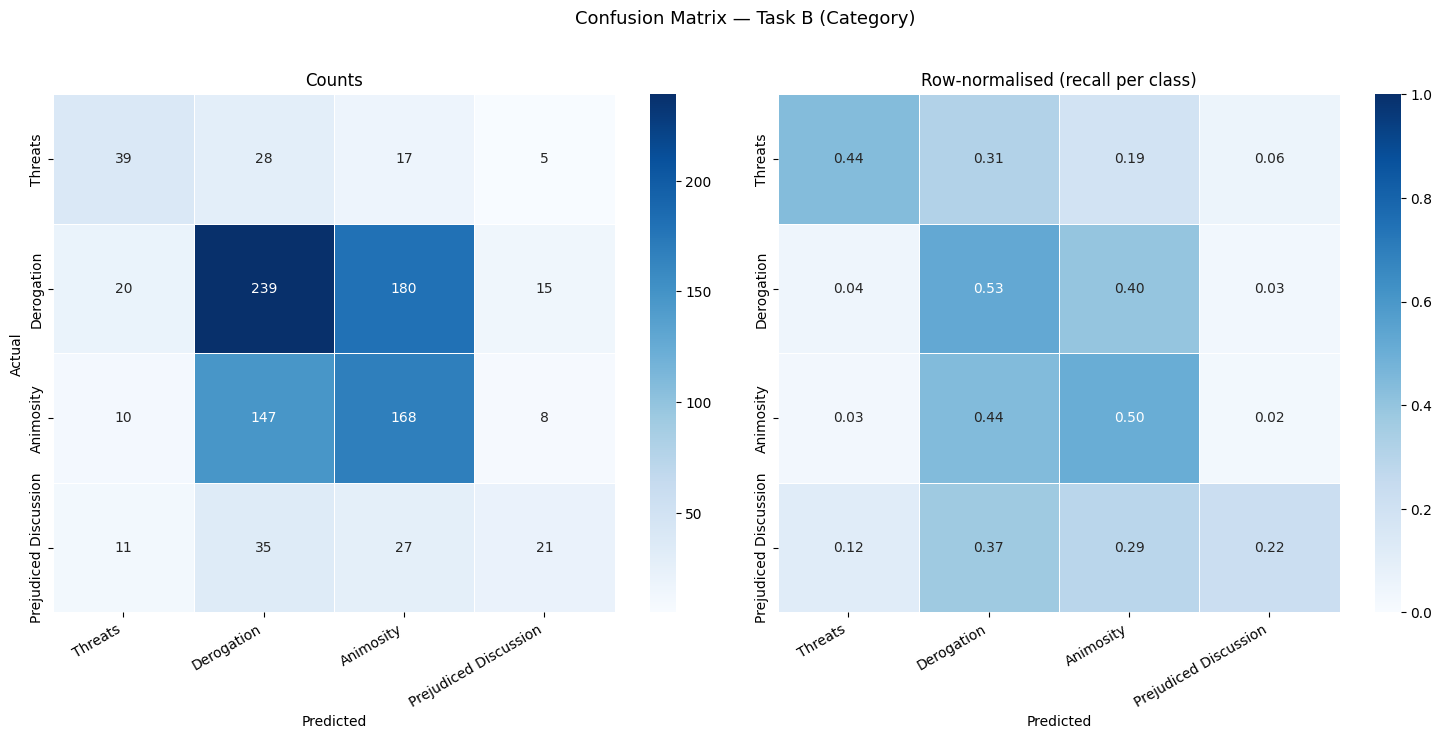

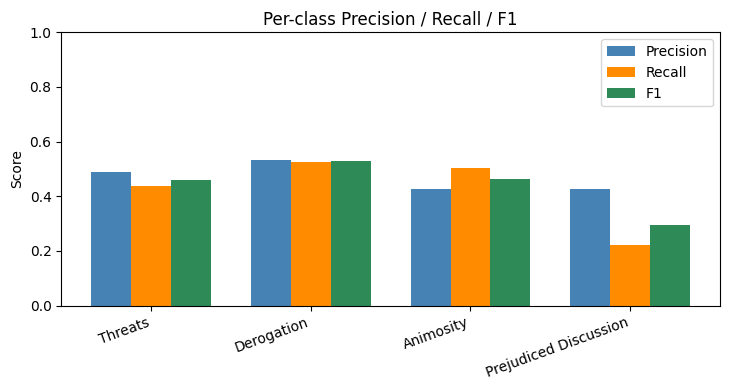


ERROR ANALYSIS

Total errors: 503 / 970 (51.9%)

Error rate per true class:


,class,errors,total,error_rate (%)
3,Prejudiced Discussion,73,94,77.7
0,Threats,50,89,56.2
2,Animosity,165,333,49.5
1,Derogation,215,454,47.4



Top confusion pairs (actual → predicted):


,actual,predicted,count
3,Derogation,Animosity,180
0,Animosity,Derogation,147
7,Prejudiced Discussion,Derogation,35
10,Threats,Derogation,28
6,Prejudiced Discussion,Animosity,27
5,Derogation,Threats,20
9,Threats,Animosity,17
4,Derogation,Prejudiced Discussion,15
8,Prejudiced Discussion,Threats,11
2,Animosity,Threats,10


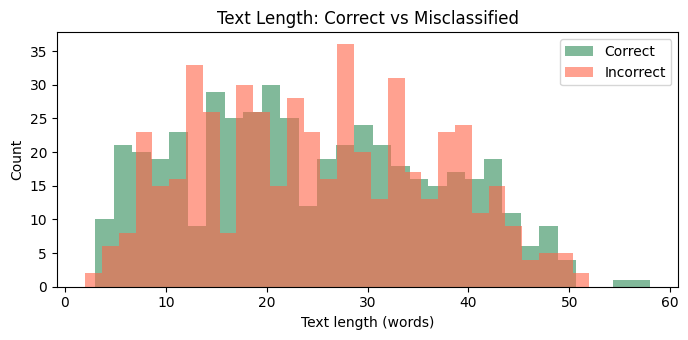


Sample misclassified examples:

  ✗ Actual: [Derogation]  →  Predicted: [Animosity]  (n = 180)
    • (0.98) yes, normal women want to be dominated. social scientists call it female hypergamy. and it is why women make bad bosses 
    • (0.62) she didn't have to be a bitch about it. she literally went out of her way to rub the rejection in his face, when a simpl
    • (0.98) if you don't want your mother fucked, keep her off the streets

  ✗ Actual: [Animosity]  →  Predicted: [Derogation]  (n = 147)
    • (0.87) 10/10 with interior decorating skills like yours, girls will be falling all over you. i'm falling for you a little mysel
    • (0.99) typical praising of women and bashing of men. they're so predictable. and dumb.
    • (0.98) most here would fuck her.

  ✗ Actual: [Prejudiced Discussion]  →  Predicted: [Derogation]  (n = 35)
    • (0.95) isn't it convenient that she doesn't have the video of this guy threatening to kill her! she films every moment of her l
    • (0.99) yes, it 

In [3]:
rnn_category = run_rnn_category(state, device)


roberta-base — Task A (Binary)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


...

5      0.2112     0.9491    0.9315    0.8685    0.8242    LR: 1.33e-05


6      0.1563     0.9697    0.9589    0.8625    0.8178    LR: 1.27e-05


7      0.1273     0.9771    0.9689    0.8758    0.8284    LR: 1.20e-05


8      0.0858     0.9854    0.9802    0.8742    0.8221    LR: 1.13e-05


9      0.0725     0.9881    0.9839    0.8770    0.8270    LR: 1.07e-05

Early stopping triggered

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not sexist       0.91      0.93      0.92      3030
      Sexist       0.77      0.70      0.73       970

    accuracy                           0.88      4000
   macro avg       0.84      0.82      0.83      4000
weighted avg       0.87      0.88      0.87      4000

Accuracy : 0.8770
Macro F1 : 0.8270
Weighted F1 : 0.8749

Confusion Matrix (raw):
[[2829  201]
 [ 291  679]]


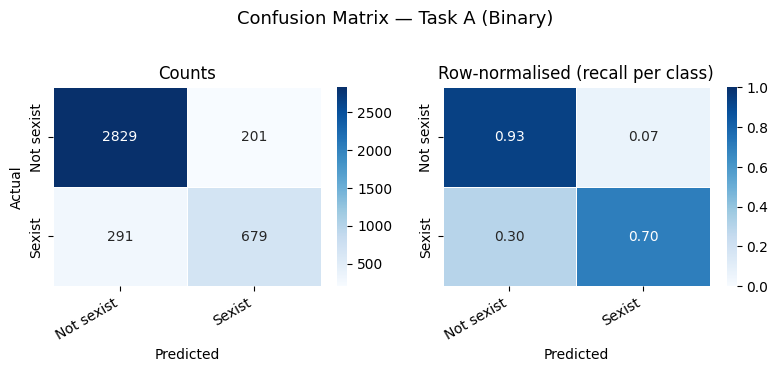

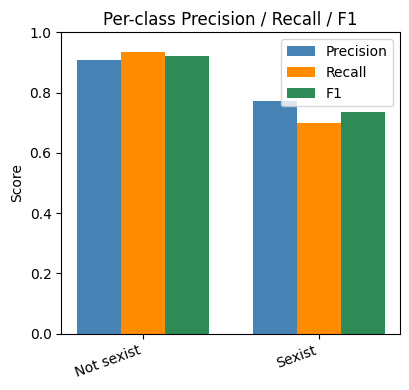


ERROR ANALYSIS

Total errors: 492 / 4000 (12.3%)

Error rate per true class:


,class,errors,total,error_rate (%)
1,Sexist,291,970,30.0
0,Not sexist,201,3030,6.6



Top confusion pairs (actual → predicted):


,actual,predicted,count
1,Sexist,Not sexist,291
0,Not sexist,Sexist,201


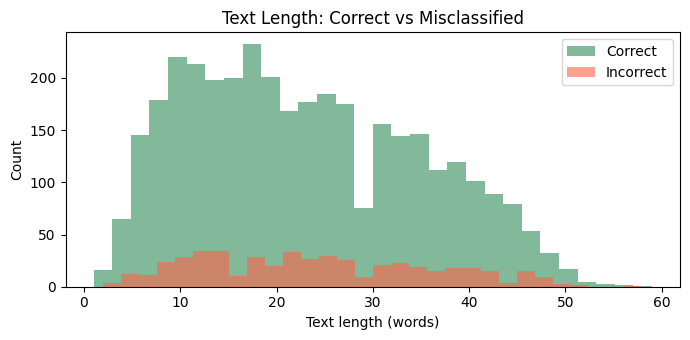


Sample misclassified examples:

  ✗ Actual: [Sexist]  →  Predicted: [Not sexist]  (n = 291)
    • (1.00) i would pay to see her ass cracker. #nsfw
    • (1.00) 10/10 with interior decorating skills like yours, girls will be falling all over you. i'm falling for you a little mysel
    • (1.00) isn't it convenient that she doesn't have the video of this guy threatening to kill her! she films every moment of her l

  ✗ Actual: [Not sexist]  →  Predicted: [Sexist]  (n = 201)
    • (0.99) most men know instinctually the game. but their ego's are so fucking big that they think, not mine, not me. bang bang sh
    • (1.00) welcome to gender equality. suck it!
    • (1.00) the iron maiden, the toughest tranny in town.

Results logged → /content/drive/MyDrive/Explainable Detection of Online Sexism/results/results_binary.csv


In [4]:
tf_binary = run_transformer_binary(state, device)


roberta-base — Task B (Category)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      1.3855     0.2140    0.1780    0.4722    0.2037    LR: 6.00e-06


...

7      0.2448     0.8708    0.9008    0.5876    0.5447    LR: 1.20e-05


8      0.1620     0.9112    0.9338    0.6165    0.5928    LR: 1.13e-05


9      0.1094     0.9490    0.9630    0.6134    0.5766    LR: 1.07e-05


10     0.0747     0.9668    0.9758    0.6227    0.5979    LR: 1.00e-05


11     0.0602     0.9781    0.9824    0.6216    0.6029    LR: 9.33e-06

Early stopping triggered

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

              Threats       0.70      0.64      0.67        89
           Derogation       0.67      0.63      0.65       454
            Animosity       0.56      0.67      0.61       333
Prejudiced Discussion       0.58      0.41      0.48        94

             accuracy                           0.62       970
            macro avg       0.63      0.59      0.60       970
         weighted avg       0.63      0.62      0.62       970

Accuracy : 0.6216
Macro F1 : 0.6029
Weighted F1 : 0.6209

Confusion Matrix (raw):
[[ 57  10  19   3]
 [ 15 285 137  17]
 [  5  98 222   8]
 [  4  30  21  39]]


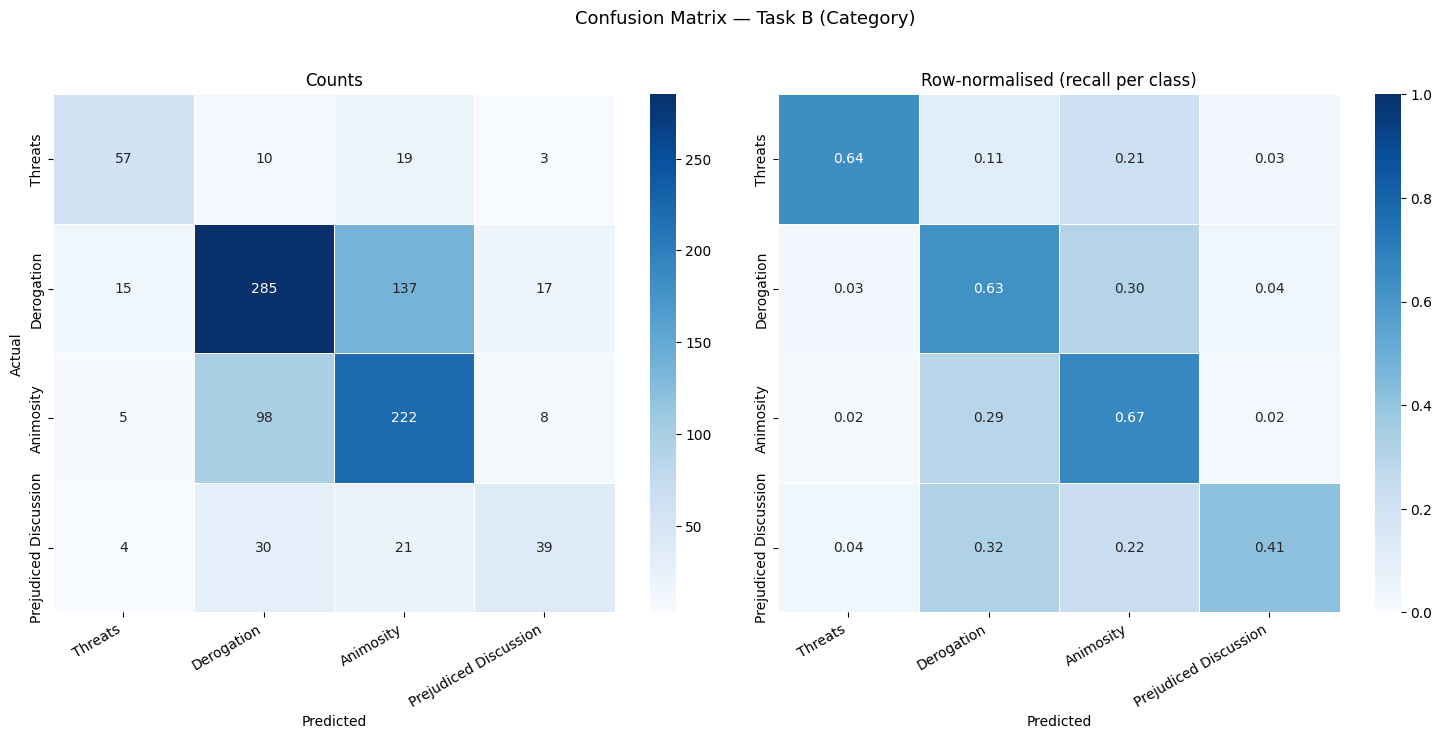

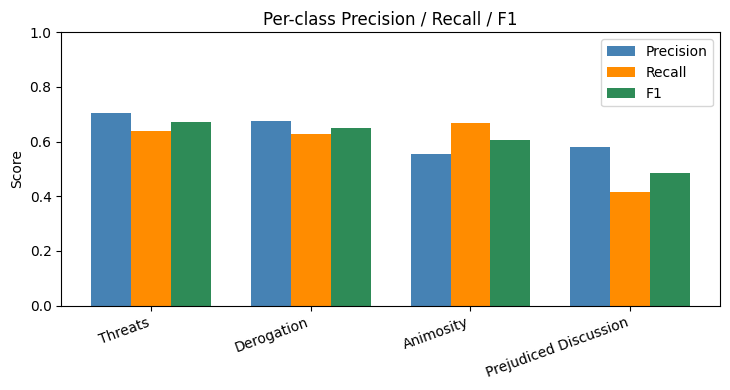


ERROR ANALYSIS

Total errors: 367 / 970 (37.8%)

Error rate per true class:


,class,errors,total,error_rate (%)
3,Prejudiced Discussion,55,94,58.5
1,Derogation,169,454,37.2
0,Threats,32,89,36.0
2,Animosity,111,333,33.3



Top confusion pairs (actual → predicted):


,actual,predicted,count
3,Derogation,Animosity,137
0,Animosity,Derogation,98
7,Prejudiced Discussion,Derogation,30
6,Prejudiced Discussion,Animosity,21
9,Threats,Animosity,19
4,Derogation,Prejudiced Discussion,17
5,Derogation,Threats,15
10,Threats,Derogation,10
1,Animosity,Prejudiced Discussion,8
2,Animosity,Threats,5


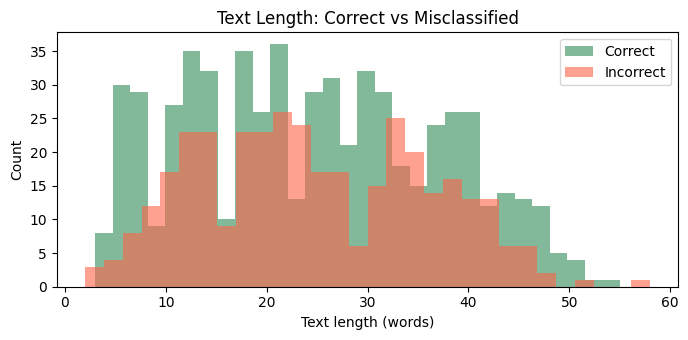


Sample misclassified examples:

  ✗ Actual: [Derogation]  →  Predicted: [Animosity]  (n = 137)
    • (1.00) yes, normal women want to be dominated. social scientists call it female hypergamy. and it is why women make bad bosses 
    • (1.00) she didn't have to be a bitch about it. she literally went out of her way to rub the rejection in his face, when a simpl
    • (1.00) i bet her future husband won't have anywhere near that much sex during his marriage lifetime with her.

  ✗ Actual: [Animosity]  →  Predicted: [Derogation]  (n = 98)
    • (1.00) typical praising of women and bashing of men. they're so predictable. and dumb.
    • (1.00) most here would fuck her.
    • (1.00) #feminist looks to have sex with #nazis on #tinder. she even is a vegetarian, and an artist just like #hitler was! does 

  ✗ Actual: [Prejudiced Discussion]  →  Predicted: [Derogation]  (n = 30)
    • (1.00) yes, it is new. what remains constant is that feminists are playing to the fears of women to instill ha

In [5]:
tf_category = run_transformer_category(state, device)